In [1]:
import os
ROOT = os.path.dirname(os.path.dirname(os.getcwd()))
print(ROOT)

/home/saisampathkedari/MonteCarlo-Statistical-Methods


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

In [ ]:
from utils.montecarlo import *
from mcmc.algorithms.metropolis_hastings import *
from mcmc.utils.mcmc_utils import *
from mcmc.diagnostics.autocorrelation import *
from mcmc.utils.run_helpers import *
from mcmc.diagnostics.iac_and_ess import *

## Target Disribution : 2D Gaussian Distribution

In [4]:
target_mean = np.array([1,2])
target_cov = build_2D_covariance_matrix(1,1,0.5)

target_pdf_2DGaussian = lambda x: multivariate_normal_pdf_eval(x.reshape(1,-1), mean=target_mean, cov=target_cov)
target_logpdf_2DGaussian = lambda x: multivariate_normal_logpdf_eval(x.reshape(1,-1), mean=target_mean, cov=target_cov)

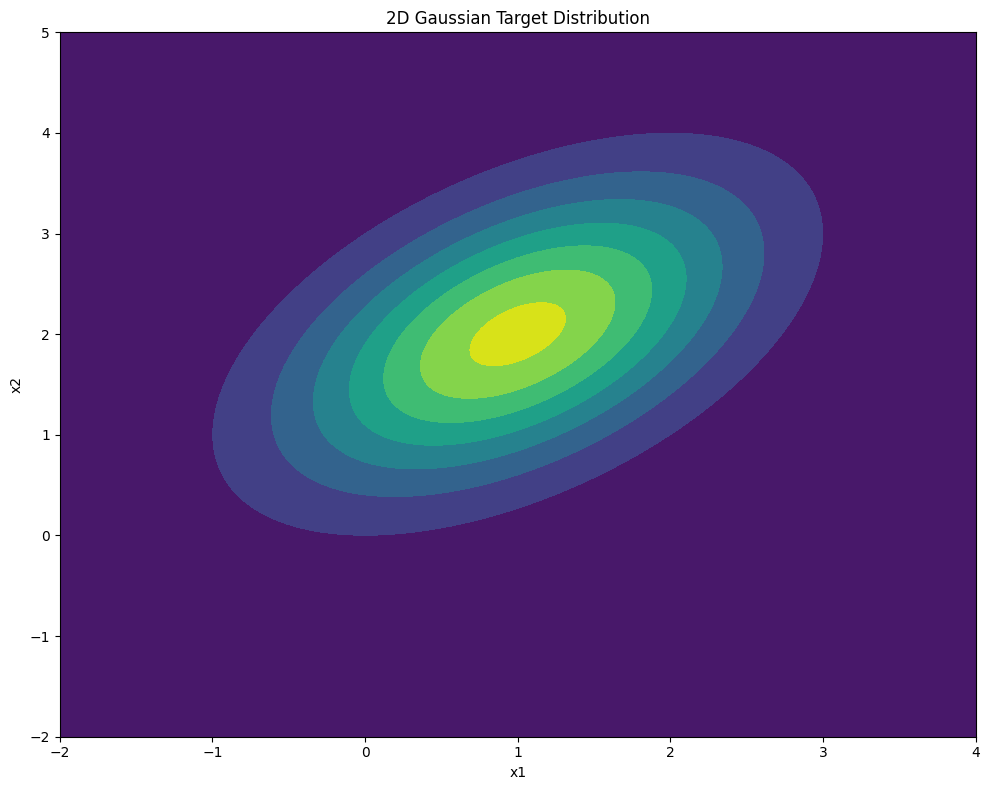

In [5]:
plt.figure(1, figsize=(10,8))

xgrid = np.linspace(-2,4,400)
ygrid = np.linspace(-2,5,400)

XX, YY, logpdf_evals = eval_on_2D_grid(xgrid, ygrid, target_pdf_2DGaussian)

plt.contourf(XX, YY, logpdf_evals)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Gaussian Target Distribution")
save_path_1 = os.path.join(ROOT, "images/mcmc/2D_Gaussian_target_distribution.png")
plt.tight_layout()
plt.savefig(save_path_1)
plt.show()

## Target Distribution and Laplace Approximation

In this section we derive a Laplace approximation for our two-dimensional Gaussian target
distribution. Although the approximation is exact for a Gaussian, we include this section
because the same workflow applies to non-Gaussian targets (e.g., banana distribution).

---

### Target Distribution and Log-Density

Our target distribution is

$$
X = (x_1,x_2)^\top \sim \mathcal{N}(\mu,\Sigma)
$$

with

$$
\mu =
\begin{bmatrix}
1 \\ 2
\end{bmatrix},
\qquad
\Sigma =
\begin{bmatrix}
1 & 0.5 \\
0.5 & 1
\end{bmatrix}.
$$

The unnormalized log-density is

$$
\log \pi(\theta)
=
-\tfrac12 (\theta - \mu)^\top \Sigma^{-1} (\theta - \mu)
+ \text{constant},
\qquad
\theta =
\begin{bmatrix}
x_1 \\ x_2
\end{bmatrix}.
$$

From Gaussian identities:

$$
\nabla \log \pi(\theta) = -\Sigma^{-1}(\theta - \mu)
$$

$$
\nabla^2 \log \pi(\theta) = -\Sigma^{-1}
$$

---

### MAP Estimate

The MAP point satisfies

$$
\nabla \log \pi(\theta^{MAP}) = 0
\quad\Longleftrightarrow\quad
\Sigma^{-1}(\theta^{MAP} - \mu) = 0.
$$

Thus,

$$
\theta^{MAP} =
\begin{bmatrix}
1 \\ 2
\end{bmatrix}
$$

---

### Laplace Covariance Estimate

The Laplace approximation fits a Gaussian

$$
\mathcal{N}(m, C)
$$

with

$$
m = \theta^{MAP},
\qquad
C = \left[-\nabla^2 \log \pi(\theta^{MAP})\right]^{-1}.
$$

For this Gaussian target:

$$
\nabla^2 \log \pi(\theta^{MAP}) = -\Sigma^{-1}
$$

$$
C = (\Sigma^{-1})^{-1} = \Sigma.
$$

So the Laplace covariance exactly matches the true covariance.

---

### Laplace-Based Initialization for MCMC

Laplace approximation provides:

- **Initialization**
  
  $$
  \theta_0 = \theta^{MAP}
  $$

- **Curvature (proposal scale)**

  $$
  C = \left[-\nabla^2 \log \pi(\theta^{MAP})\right]^{-1}
  $$

- **Proposal covariance (scaled)**

  $$
  \Sigma_{\text{prop}} = \kappa\, C
  $$

This typically yields:

- shorter burn-in  
- better early acceptance  
- improved scaling in stiff directions  

Even though this example is Gaussian (Laplace is exact), this lays the foundation for using
Laplace initialization on complex distributions later.

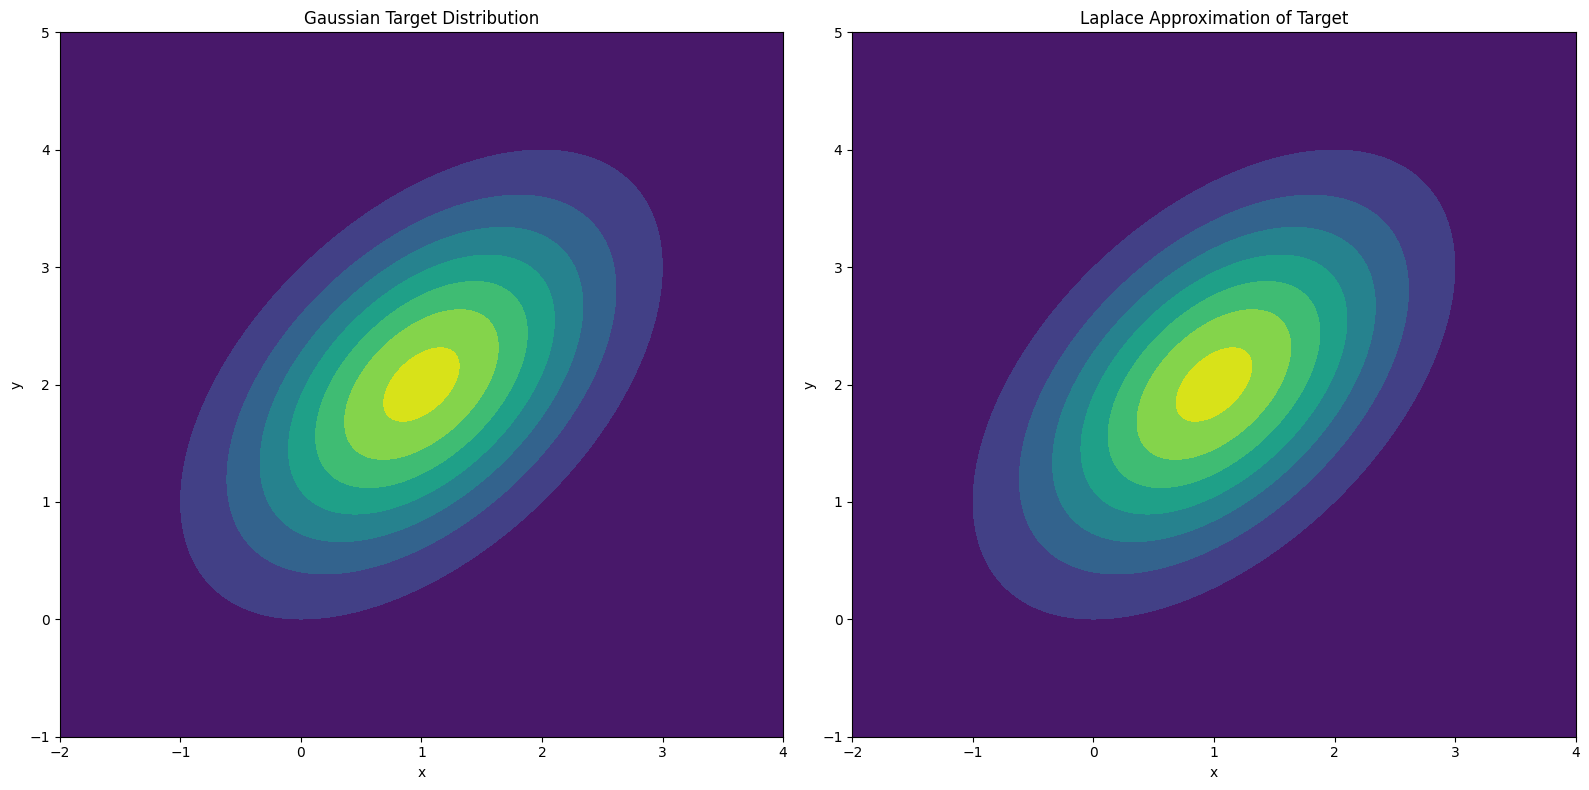

In [6]:
# -------------------------------------------------------
# 1. Define the grid
# -------------------------------------------------------
xgrid = np.linspace(-2, 4, 300)
ygrid = np.linspace(-1, 5, 300)

# -------------------------------------------------------
# 2. Evaluate Target distribution
# -------------------------------------------------------
XX, YY, target_vals = eval_on_2D_grid(
    xgrid,
    ygrid,
    target_pdf_2DGaussian)

# -------------------------------------------------------
# 3. Evaluate Laplace Approximation (Gaussian)
# -------------------------------------------------------
gauss_mean = np.array([1, 2])
gauss_cov = build_2D_covariance_matrix(1.0, 1.0, 0.5)

# Use scipy Gaussian evaluator on grid
XX, YY, laplace_target_vals = eval_on_2D_grid(
    xgrid,
    ygrid,
    target_pdf_2DGaussian)

# -------------------------------------------------------
# 4. Plot both distributions
# -------------------------------------------------------
plt.figure(figsize=(16, 8))

# Left subplot: Target Distribution
ax1 = plt.subplot(1, 2, 1)
ax1.contourf(XX, YY, target_vals)
ax1.set_title("Gaussian Target Distribution")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_xlim(-2, 4)
ax1.set_ylim(-1, 5)

# Right subplot: Laplace approximation
ax2 = plt.subplot(1, 2, 2)
ax2.contourf(XX, YY, laplace_target_vals)
ax2.set_title("Laplace Approximation of Target")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_xlim(-2, 4)
ax2.set_ylim(-1, 5)

plt.tight_layout()
plt.show()


# Metropolis-Hastings for 2D Gaussian Distribution

In [7]:
def proposal_rw_sampler(x: np.ndarray, std: float = 1.0) ->np.ndarray:
    """Sample from a random walk proposal with identity covariance."""
    return x + std* np.random.randn(x.shape[0])

def proposal_rw_logpdf(x: np.ndarray, y: np.ndarray, std: float = 1.0) -> float:
    """
    Log-density of the Gaussian random-walk proposal:
        y | x ~ N(x, std^2 * I)
    Probability of moving from x to y (in this case it is symmetric).
    """
    d = x.shape[0]
    delta = y - x
    constant = -0.5*d*np.log(2*np.pi)
    
    logpdf = constant - d*np.log(std) - 0.5*np.dot(delta, delta)/(std * std)
    return logpdf

In [8]:
initial_sample = np.array([10,10])
num_samples = 10000
target_logpdf = lambda x: multivariate_normal_logpdf_eval(x.reshape(1,-1), mean=target_mean, cov=target_cov)
proposal_logpdf = lambda x, y: proposal_rw_logpdf(x,y, std=2)
proposal_sampler = lambda x: proposal_rw_sampler(x, std=2)

mh_samples = mh_mcmc(initial_sample, num_samples, target_logpdf, proposal_logpdf, proposal_sampler)

samples = mh_samples.samples
print("Accepted Samples Ratio:", mh_samples.accept_rate)

Accepted Samples Ratio: 0.2627262726272627


## Burn-in

In [9]:
new_mh_result= mcmc_burnin_and_thin(mh_samples, burnin_frac=0.5, thin_frac=1)
samples = new_mh_result.samples
print("Accepted Samples Ratio:", new_mh_result.accept_rate)

Accepted Samples Ratio: 0.2548


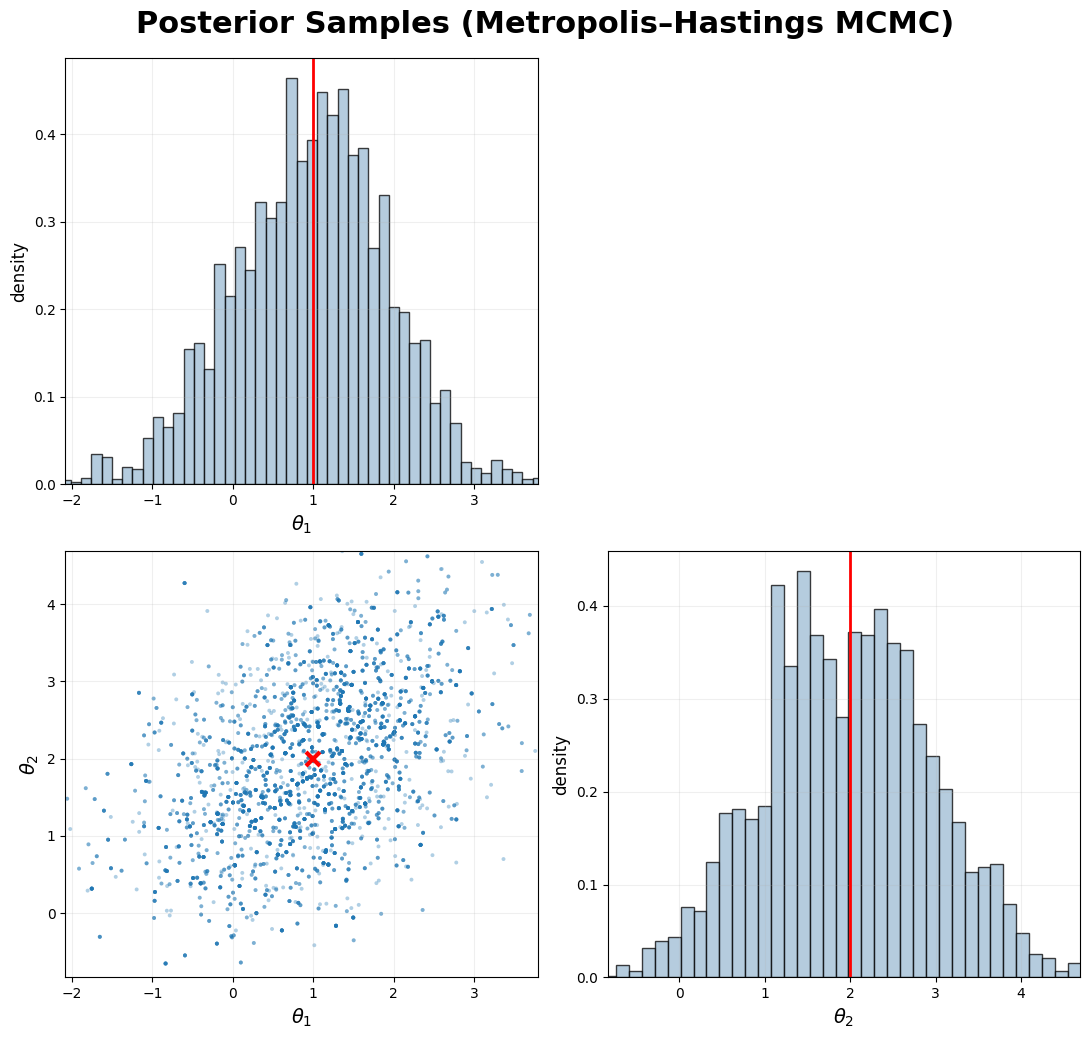

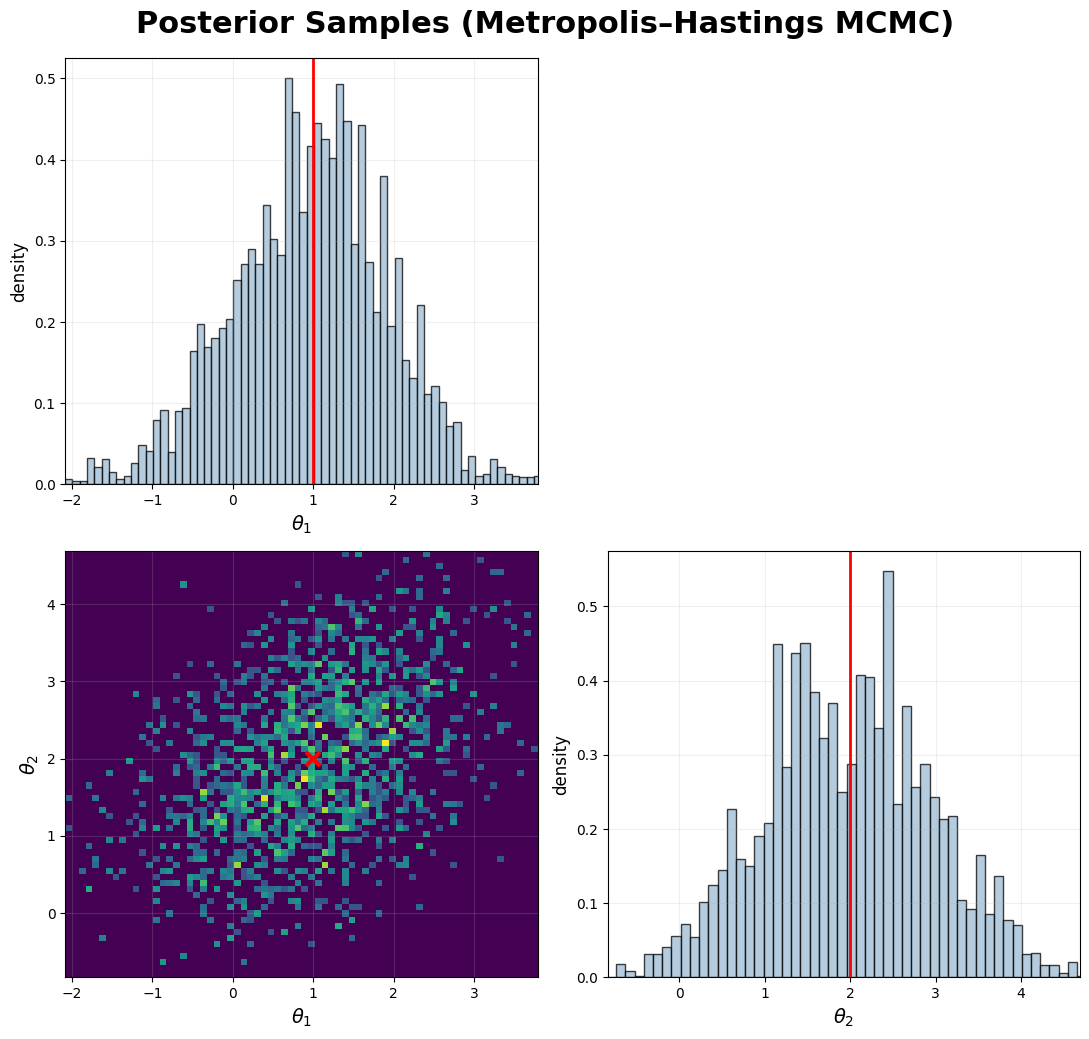

In [10]:
plt.close()
fig, axs, gs = scatter_matrix_clean(
    11,
    [samples],
    truths=gauss_mean,          # or None
    labels=[r"$\theta_1$", r"$\theta_2$"],
    hist_plot=False,
)
plt.show()

plt.close(12)
fig, axs, gs = scatter_matrix_clean(
    12,
    [samples],
    truths=gauss_mean,
    labels=[r"$\theta_1$", r"$\theta_2$"],
    hist_plot=True,
    nbins=70
)
plt.show()

## Estimation of Mean

In [11]:
print("True Mean        = ", target_mean)
print("Estimated Mean   = ", np.mean(samples, axis=0))

True Mean        =  [1 2]
Estimated Mean   =  [0.96665204 1.96261451]


## Mixing

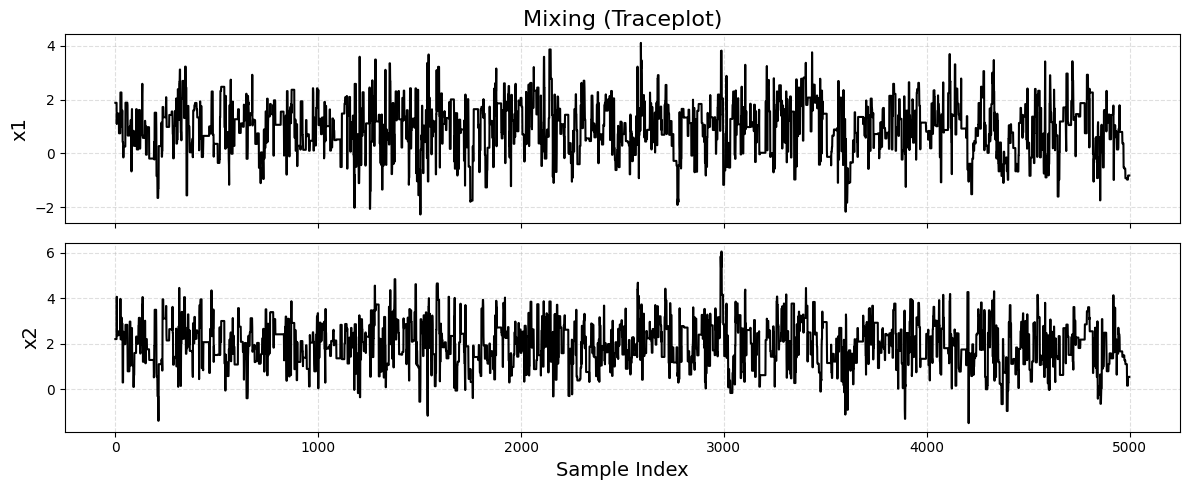

In [12]:
plot_mixing_2d(samples, dim_names=("x1", "x2"))

## Autocorrelation

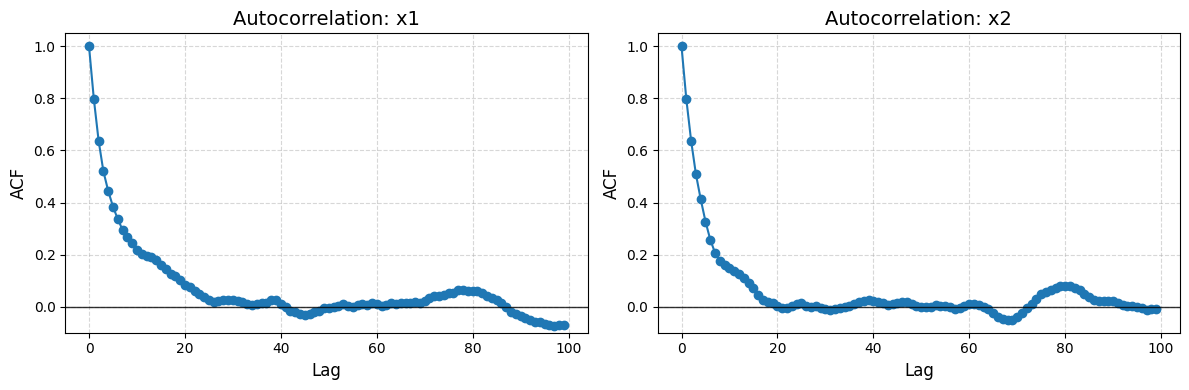

In [13]:
lags, acf = autocorrelation_vectorized(samples, max_lag=100)
plot_autocorrelation_2d(lags, acf, dim_names=("x1", "x2"))

## Integrated Auto-Correlation & Effective Sample Size

In [15]:
iac, acf, lags = integrated_autocorrelation(samples, max_lag=300)
ess = effective_sample_size(samples, iac)

N = samples.shape[0]
efficiency = ess / N * 100  # percentage

print(f"Total samples: {N}\n")

for k in range(len(iac)):
    print(f"Dimension {k}:")
    print(f"  IAC:          {iac[k]:.4f}")
    print(f"  ESS:          {ess[k]:.2f}")
    print(f"  Efficiency:   {efficiency[k]:.1f}%   "
          f"({efficiency[k]:.1f}% as effective as independent samples)")
    print()


Total samples: 5000

Dimension 0:
  IAC:          13.3328
  ESS:          375.01
  Efficiency:   7.5%   (7.5% as effective as independent samples)

Dimension 1:
  IAC:          9.5504
  ESS:          523.54
  Efficiency:   10.5%   (10.5% as effective as independent samples)

